In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [4]:
df = pd.read_csv("QVI_data.csv")

In [5]:
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [9]:
df['DATE'] = pd.to_datetime(df['DATE'])
print("Shape:", df.shape)
print("Date range:", df['DATE'].min(), "to", df['DATE'].max())
print("Unique Stores:", df['STORE_NBR'].nunique())

Shape: (264834, 12)
Date range: 2018-07-01 00:00:00 to 2019-06-30 00:00:00
Unique Stores: 272


In [10]:
df['MONTH_YEAR'] = df['DATE'].dt.to_period('M')

In [11]:
monthly_store = df.groupby(
    ['STORE_NBR', 'MONTH_YEAR']
).agg(
    TOTAL_SALES   = ('TOT_SALES',      'sum'),
    NUM_CUSTOMERS = ('LYLTY_CARD_NBR', 'nunique'),
    NUM_TXN       = ('TXN_ID',         'count')
).reset_index()

# Avg transactions per customer
monthly_store['AVG_TXN_PER_CUSTOMER'] = (
    monthly_store['NUM_TXN'] / monthly_store['NUM_CUSTOMERS']
)

print("\nMonthly Store Metrics (first 10 rows):")
print(monthly_store.head(10))
print(f"\nShape: {monthly_store.shape}")
print(f"Unique Stores: {monthly_store['STORE_NBR'].nunique()}")


Monthly Store Metrics (first 10 rows):
   STORE_NBR MONTH_YEAR  TOTAL_SALES  NUM_CUSTOMERS  NUM_TXN  \
0          1    2018-07        206.9             49       52   
1          1    2018-08        176.1             42       43   
2          1    2018-09        278.8             59       62   
3          1    2018-10        188.1             44       45   
4          1    2018-11        192.6             46       47   
5          1    2018-12        189.6             42       47   
6          1    2019-01        154.8             35       36   
7          1    2019-02        225.4             52       55   
8          1    2019-03        192.9             45       49   
9          1    2019-04        192.9             42       43   

   AVG_TXN_PER_CUSTOMER  
0              1.061224  
1              1.023810  
2              1.050847  
3              1.022727  
4              1.021739  
5              1.119048  
6              1.028571  
7              1.057692  
8              1.0888

In [12]:
trial_stores = [77, 86, 88]
for store in trial_stores:
    exists = store in df['STORE_NBR'].values
    print(f"Store {store} exists in data: {exists}")

Store 77 exists in data: True
Store 86 exists in data: True
Store 88 exists in data: True


In [13]:
# DEFINE TRIAL PERIOD 
monthly_store['MONTH_YEAR'] = monthly_store['MONTH_YEAR'].astype(str)
# Pre-trial = everything before Feb 2019
pre_trial = monthly_store[monthly_store['MONTH_YEAR'] < '2019-02']
# Trial period = Feb to Apr 2019
trial_period = monthly_store[
    (monthly_store['MONTH_YEAR'] >= '2019-02') &
    (monthly_store['MONTH_YEAR'] <= '2019-04')
]
print("Pre-trial months  :", sorted(pre_trial['MONTH_YEAR'].unique()))
print("Trial months      :", sorted(trial_period['MONTH_YEAR'].unique()))

#  CORRELATION FUNCTION 
def get_correlation(trial_store_nbr, control_store_nbr, metric):
    trial_data = pre_trial[pre_trial['STORE_NBR'] == trial_store_nbr][metric].values
    control_data = pre_trial[pre_trial['STORE_NBR'] == control_store_nbr][metric].values
    if len(trial_data) != len(control_data):
        return 0
    
    correlation, _ = stats.pearsonr(trial_data, control_data)
    return correlation

#  MAGNITUDE DISTANCE FUNCTION 
def get_magnitude(trial_store_nbr, control_store_nbr, metric):
    trial_val   = pre_trial[pre_trial['STORE_NBR'] == trial_store_nbr][metric].mean()
    control_val = pre_trial[ pre_trial['STORE_NBR'] == control_store_nbr][metric].mean()
    distance = abs(trial_val - control_val)
    return distance

# FIND BEST CONTROL STORE FUNCTION
def find_control_store(trial_store_nbr):
    control_candidates = [s for s in monthly_store['STORE_NBR'].unique()if s not in [77, 86, 88]]
    metrics = ['TOTAL_SALES', 'NUM_CUSTOMERS', 'AVG_TXN_PER_CUSTOMER']
    results = []
    for control in control_candidates:
        scores = {'STORE_NBR': control}

        for m in metrics:
            scores[f'CORR_{m}'] = get_correlation(
                trial_store_nbr, control, m
            )
        for m in metrics:
            scores[f'DIST_{m}'] = get_magnitude(
                trial_store_nbr, control, m
            )

        results.append(scores)
    results_df = pd.DataFrame(results)

    for m in metrics:
        col = f'DIST_{m}'
        min_d = results_df[col].min()
        max_d = results_df[col].max()
        results_df[f'MAG_{m}'] = (
            1 - (results_df[col] - min_d) / (max_d - min_d)
        )

    results_df['FINAL_SCORE'] = (
        results_df['CORR_TOTAL_SALES'] +
        results_df['CORR_NUM_CUSTOMERS'] +
        results_df['CORR_AVG_TXN_PER_CUSTOMER'] +
        results_df['MAG_TOTAL_SALES'] +
        results_df['MAG_NUM_CUSTOMERS'] +
        results_df['MAG_AVG_TXN_PER_CUSTOMER']) / 6
    
    best_control = results_df.sort_values('FINAL_SCORE', ascending=False).iloc[0]

    print(f"\nBest control for Store {trial_store_nbr}:")
    print(f"  Control Store : {int(best_control['STORE_NBR'])}")
    print(f"  Final Score   : {best_control['FINAL_SCORE']:.4f}")
    print(f"  Corr Sales    : {best_control['CORR_TOTAL_SALES']:.4f}")
    print(f"  Corr Customers: {best_control['CORR_NUM_CUSTOMERS']:.4f}")

    return int(best_control['STORE_NBR']), results_df

# RUN FOR ALL 3 TRIAL STORES 
print("\nCONTROL STORE SELECTION")
control_77, scores_77 = find_control_store(77)
control_86, scores_86 = find_control_store(86)
control_88, scores_88 = find_control_store(88)


print("\nFINAL CONTROL STORE ASSIGNMENTS")
print(f"  Trial Store 77  →  Control Store {control_77}")
print(f"  Trial Store 86  →  Control Store {control_86}")
print(f"  Trial Store 88  →  Control Store {control_88}")

Pre-trial months  : ['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']
Trial months      : ['2019-02', '2019-03', '2019-04']

CONTROL STORE SELECTION


C:\Users\Manju\AppData\Local\Temp\ipykernel_25768\2125322644.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = stats.pearsonr(trial_data, control_data)



Best control for Store 77:
  Control Store : 17
  Final Score   : 0.8177
  Corr Sales    : 0.8427
  Corr Customers: 0.7473

Best control for Store 86:
  Control Store : 138
  Final Score   : 0.8399
  Corr Sales    : 0.7599
  Corr Customers: 0.7497

Best control for Store 88:
  Control Store : 178
  Final Score   : 0.7488
  Corr Sales    : 0.7319
  Corr Customers: 0.9395

FINAL CONTROL STORE ASSIGNMENTS
  Trial Store 77  →  Control Store 17
  Trial Store 86  →  Control Store 138
  Trial Store 88  →  Control Store 178


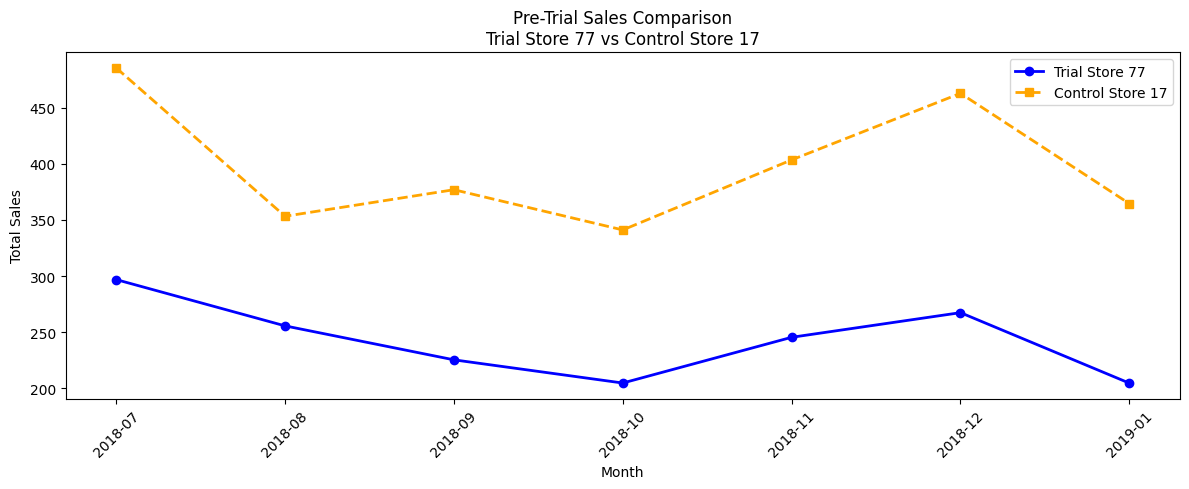

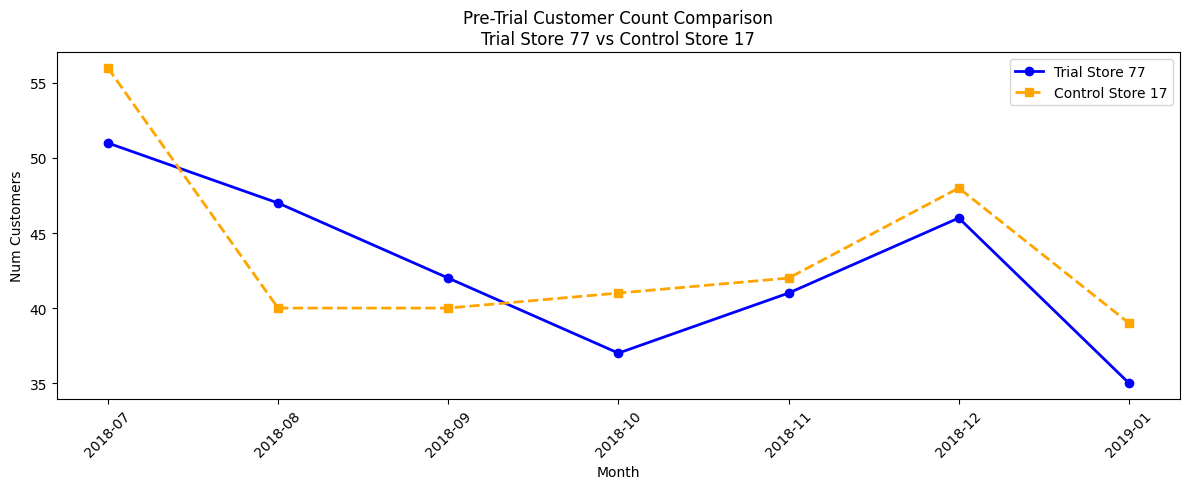

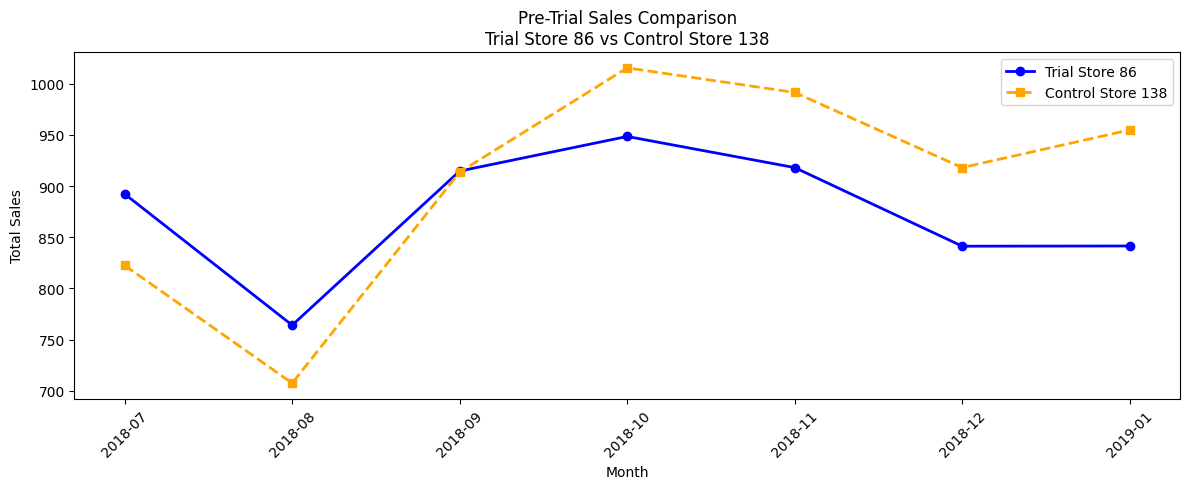

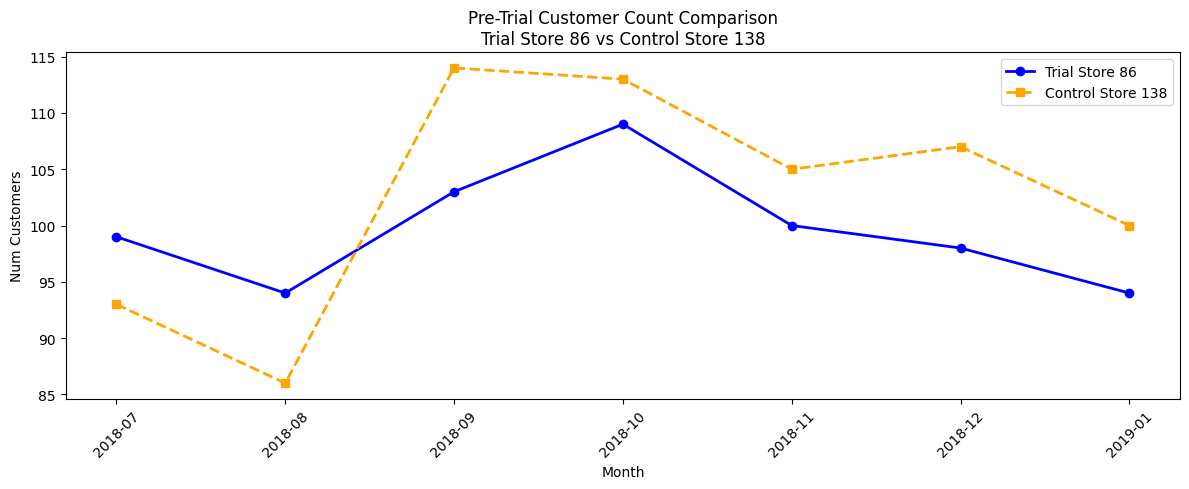

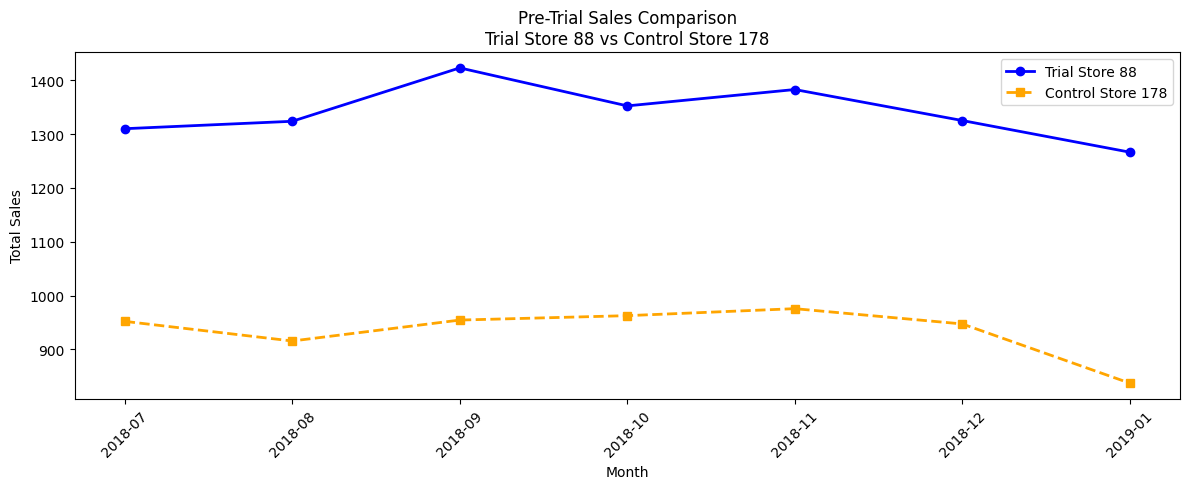

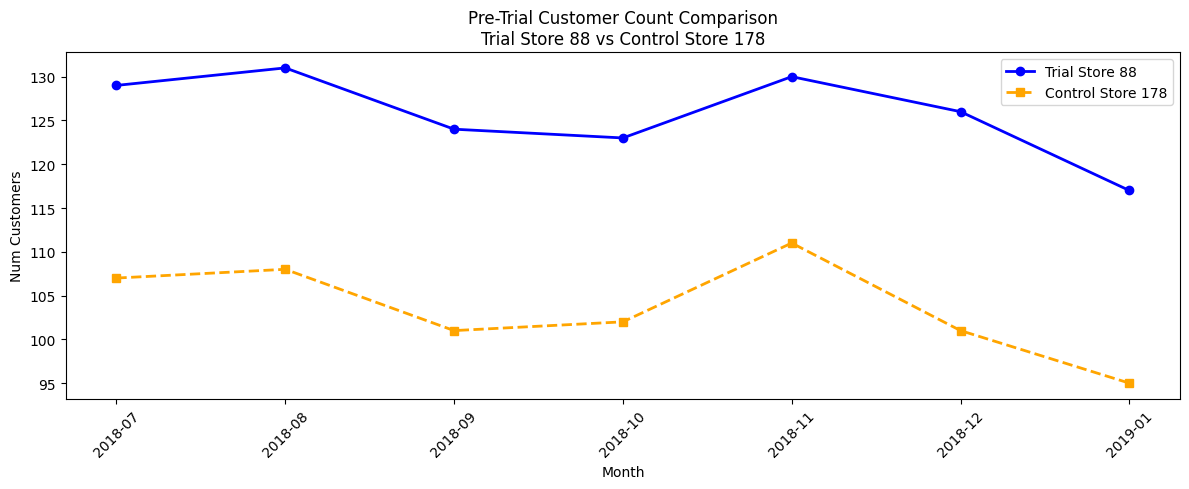

In [14]:
# VISUALISE PRE-TRIAL MATCH

def plot_pretrial_match(trial_store, control_store, metric, title):
    trial_data = pre_trial[pre_trial['STORE_NBR'] == trial_store][['MONTH_YEAR', metric]].rename(columns={metric: f'Trial Store {trial_store}'})
    control_data = pre_trial[pre_trial['STORE_NBR'] == control_store][['MONTH_YEAR', metric]].rename(columns={metric: f'Control Store {control_store}'})
    merged = trial_data.merge(control_data, on='MONTH_YEAR')

    plt.figure(figsize=(12, 5))
    plt.plot(
        merged['MONTH_YEAR'],
        merged[f'Trial Store {trial_store}'],
        marker='o', label=f'Trial Store {trial_store}',
        color='blue', linewidth=2
    )
    plt.plot(
        merged['MONTH_YEAR'],
        merged[f'Control Store {control_store}'],
        marker='s', label=f'Control Store {control_store}',
        color='orange', linewidth=2, linestyle='--'
    )
    plt.title(f'{title}\nTrial Store {trial_store} vs Control Store {control_store}')
    plt.xlabel('Month')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'pretrial_{trial_store}_{metric}.png')
    plt.show()

# PLOT ALL 3 PAIRS × TOTAL SALES 
# Store 77 vs 17
plot_pretrial_match(77, control_77, 'TOTAL_SALES',
    'Pre-Trial Sales Comparison')
plot_pretrial_match(77, control_77, 'NUM_CUSTOMERS',
    'Pre-Trial Customer Count Comparison')

# Store 86 vs 138
plot_pretrial_match(86, control_86, 'TOTAL_SALES',
    'Pre-Trial Sales Comparison')
plot_pretrial_match(86, control_86, 'NUM_CUSTOMERS',
    'Pre-Trial Customer Count Comparison')

# Store 88 vs 178
plot_pretrial_match(88, control_88, 'TOTAL_SALES',
    'Pre-Trial Sales Comparison')
plot_pretrial_match(88, control_88, 'NUM_CUSTOMERS',
    'Pre-Trial Customer Count Comparison')


   TRIAL vs CONTROL ASSESSMENT

Store 77 scaling factor: 0.6093


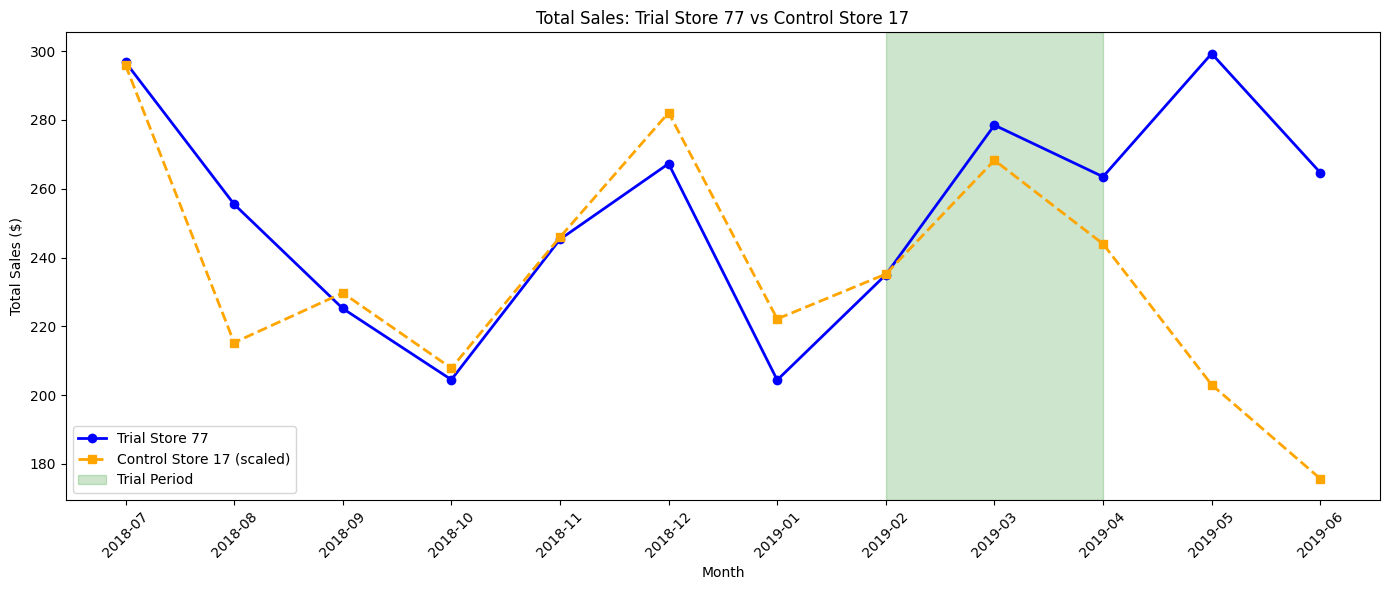

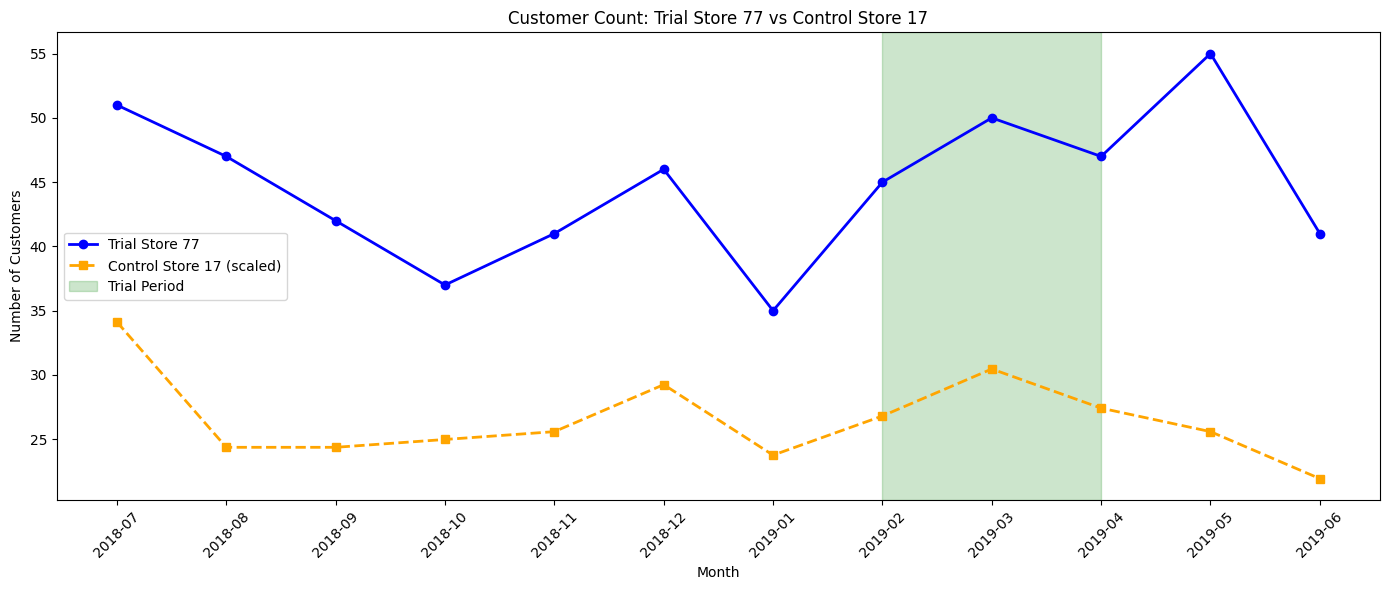


 Statistical Test: Store 77 
  Trial Period Avg Sales   : $259.00
  Control Period Avg Sales : $249.16
  Difference               : $9.84
  T-statistic              : 0.6097
  P-value                  : 0.5750
  Result: ❌ NOT significant — Could be random chance

Store 86 scaling factor: 0.9679


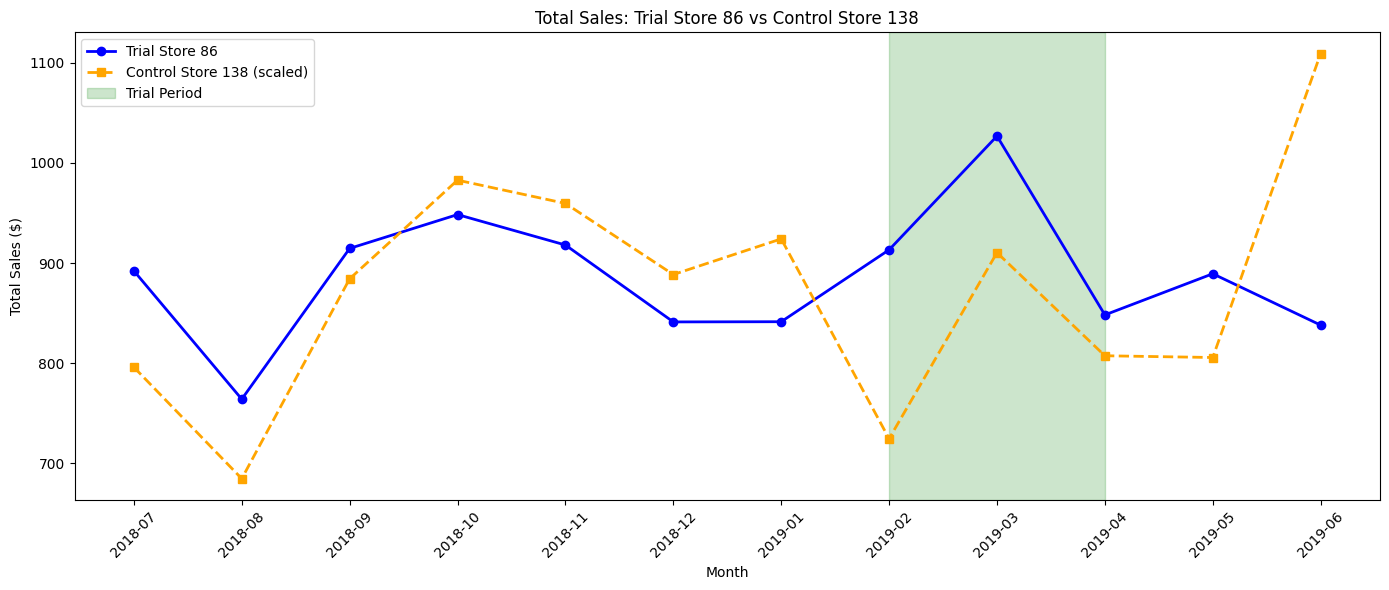

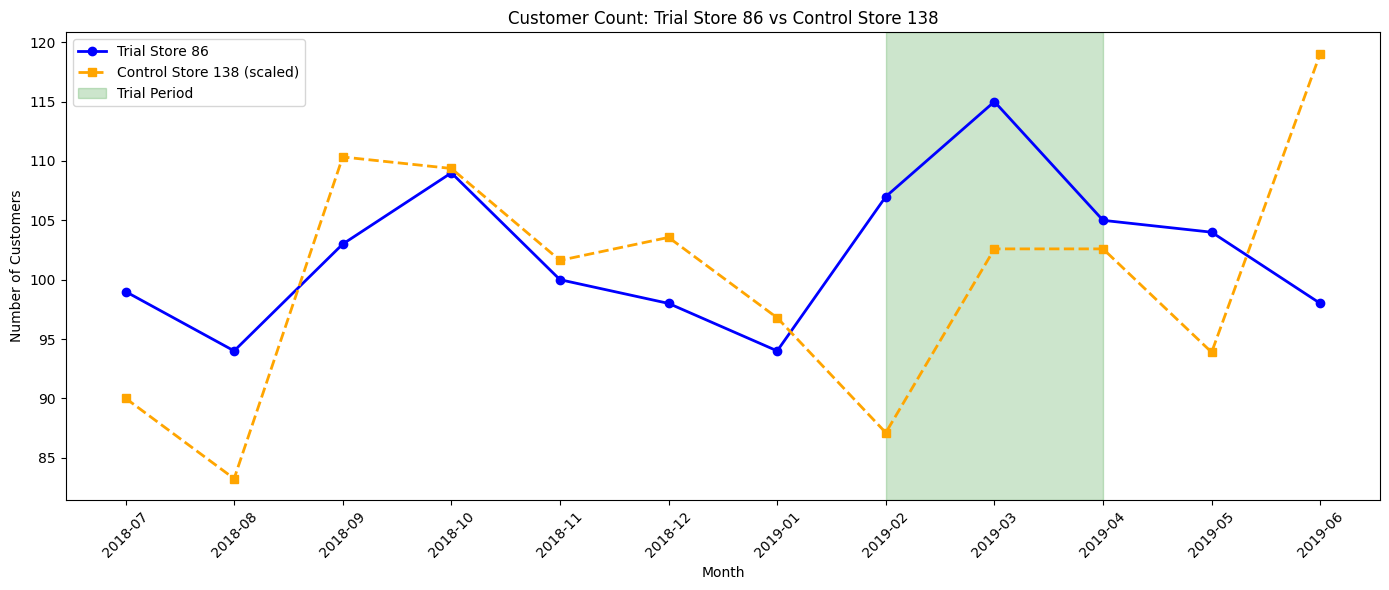


 Statistical Test: Store 86 
  Trial Period Avg Sales   : $929.40
  Control Period Avg Sales : $814.11
  Difference               : $115.29
  T-statistic              : 1.5389
  P-value                  : 0.1987
  Result: ❌ NOT significant — Could be random chance

Store 88 scaling factor: 1.4338


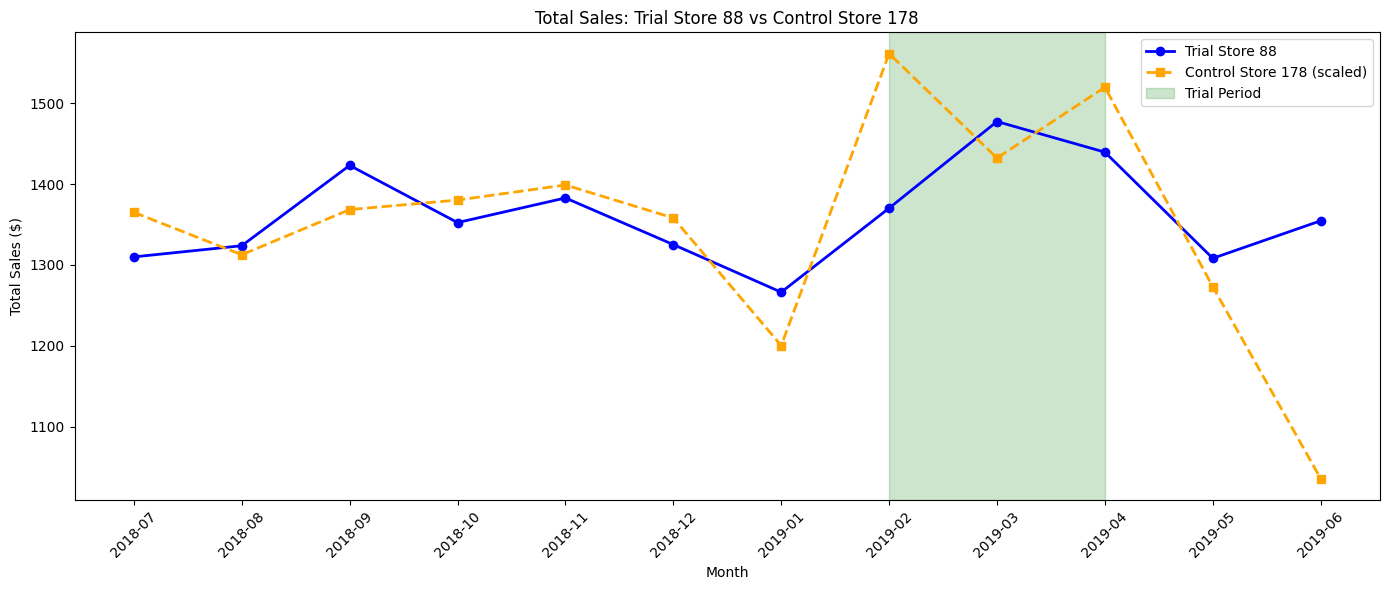

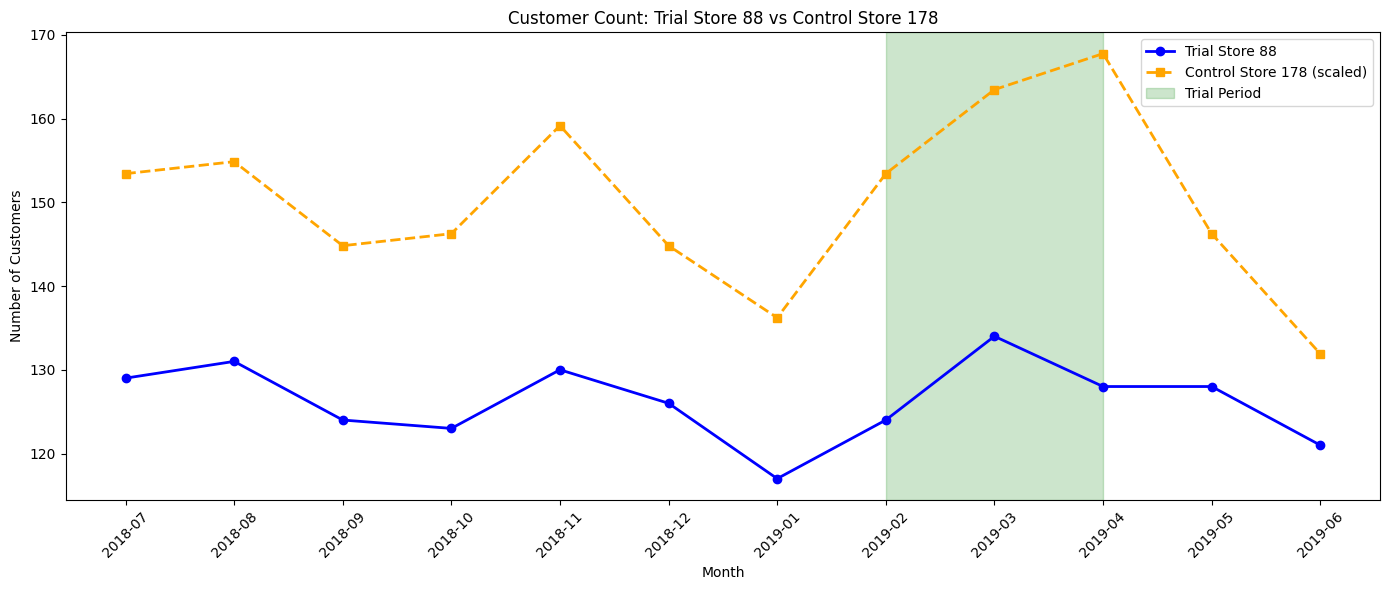


 Statistical Test: Store 88 
  Trial Period Avg Sales   : $1,428.93
  Control Period Avg Sales : $1,504.26
  Difference               : $-75.33
  T-statistic              : -1.5289
  P-value                  : 0.2010
  Result: ❌ NOT significant — Could be random chance


In [16]:
# TRIAL vs CONTROL COMPARISON 
def compare_trial_control(trial_store, control_store):
    trial_pretrial_avg = pre_trial[pre_trial['STORE_NBR'] == trial_store]['TOTAL_SALES'].mean()
    control_pretrial_avg = pre_trial[pre_trial['STORE_NBR'] == control_store]['TOTAL_SALES'].mean()
    scaling_factor = trial_pretrial_avg / control_pretrial_avg
    print(f"\nStore {trial_store} scaling factor: {scaling_factor:.4f}")
   
    trial_all = monthly_store[monthly_store['STORE_NBR'] == trial_store].copy()
    control_all = monthly_store[monthly_store['STORE_NBR'] == control_store].copy()

    control_all['TOTAL_SALES_SCALED'] = (
        control_all['TOTAL_SALES'] * scaling_factor
    )
    control_all['NUM_CUSTOMERS_SCALED'] = (
        control_all['NUM_CUSTOMERS'] * scaling_factor
    )

    # PLOT 1: Total Sales Comparison 
    plt.figure(figsize=(14, 6))
    plt.plot(
        trial_all['MONTH_YEAR'],
        trial_all['TOTAL_SALES'],
        marker='o', color='blue',
        label=f'Trial Store {trial_store}', linewidth=2
    )
    plt.plot(
        control_all['MONTH_YEAR'],
        control_all['TOTAL_SALES_SCALED'],
        marker='s', color='orange', linestyle='--',
        label=f'Control Store {control_store} (scaled)', linewidth=2
    )

    # Shade the trial period Feb-Apr 2019
    plt.axvspan(
        trial_all['MONTH_YEAR'].tolist().index('2019-02'),
        trial_all['MONTH_YEAR'].tolist().index('2019-04'),
        alpha=0.2, color='green', label='Trial Period'
    )

    plt.title(
        f'Total Sales: Trial Store {trial_store} vs '
        f'Control Store {control_store}'
    )
    plt.xlabel('Month')
    plt.ylabel('Total Sales ($)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'trial_sales_{trial_store}.png')
    plt.show()

    #PLOT 2: Customer Count Comparison
    plt.figure(figsize=(14, 6))
    plt.plot(
        trial_all['MONTH_YEAR'],
        trial_all['NUM_CUSTOMERS'],
        marker='o', color='blue',
        label=f'Trial Store {trial_store}', linewidth=2
    )
    plt.plot(
        control_all['MONTH_YEAR'],
        control_all['NUM_CUSTOMERS_SCALED'],
        marker='s', color='orange', linestyle='--',
        label=f'Control Store {control_store} (scaled)', linewidth=2
    )
    plt.axvspan(
        trial_all['MONTH_YEAR'].tolist().index('2019-02'),
        trial_all['MONTH_YEAR'].tolist().index('2019-04'),
        alpha=0.2, color='green', label='Trial Period'
    )
    plt.title(
        f'Customer Count: Trial Store {trial_store} vs '
        f'Control Store {control_store}'
    )
    plt.xlabel('Month')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'trial_customers_{trial_store}.png')
    plt.show()

    #STATISTICAL SIGNIFICANCE TEST 
    trial_sales_trial_period = trial_all[
        trial_all['MONTH_YEAR'].isin(['2019-02','2019-03','2019-04'])
    ]['TOTAL_SALES'].values

    control_sales_trial_period = control_all[
        control_all['MONTH_YEAR'].isin(['2019-02','2019-03','2019-04'])
    ]['TOTAL_SALES_SCALED'].values

    t_stat, p_value = stats.ttest_ind(
        trial_sales_trial_period,
        control_sales_trial_period
    )

    print(f"\n Statistical Test: Store {trial_store} ")
    print(f"  Trial Period Avg Sales   : "
          f"${trial_sales_trial_period.mean():,.2f}")
    print(f"  Control Period Avg Sales : "
          f"${control_sales_trial_period.mean():,.2f}")
    print(f"  Difference               : "
          f"${trial_sales_trial_period.mean() - control_sales_trial_period.mean():,.2f}")
    print(f"  T-statistic              : {t_stat:.4f}")
    print(f"  P-value                  : {p_value:.4f}")
    if p_value < 0.05:
        print(f"  Result: ✅ SIGNIFICANT — Trial had real impact!")
    else:
        print(f"  Result: ❌ NOT significant — Could be random chance")



print("   TRIAL vs CONTROL ASSESSMENT")
compare_trial_control(77, control_77)
compare_trial_control(86, control_86)
compare_trial_control(88, control_88)